In [2]:



import pandas as pd

df_temp = pd.read_csv('Ferrari.csv')

# Estimacija uslovnih i bezuslovnih verovatnoca odredjenih dogadjaja

In [5]:
#Racunamo bezuslovnu verovatnocu da je cena stock marketa bila veca od 100$

PN1 = df_temp[df_temp['Open'] > 100]

prob = len(PN1) / len (df_temp['Open'])

print(f"Verovatnoca da je cena veca od 100$ je {prob: .2f}")



#Racunamo uslovnu verovatnocu da je najveca cena prelazila 110 i da najmanja cena je bila preko 50$



PN3 = len(df_temp[(df_temp['High'] > 110) & (df_temp['Low'] > 50)]) / len(df_temp)


print(f"Verovatnoca da je najveca cena prelazila 110$ i najmanja 50$ je {PN3: .2f}")

Verovatnoca da je cena veca od 100$ je  0.76
Verovatnoca da je najveca cena prelazila 110$ i najmanja 50$ je  0.73


# Primena regresije (linearna, visestruka, nelinearna)

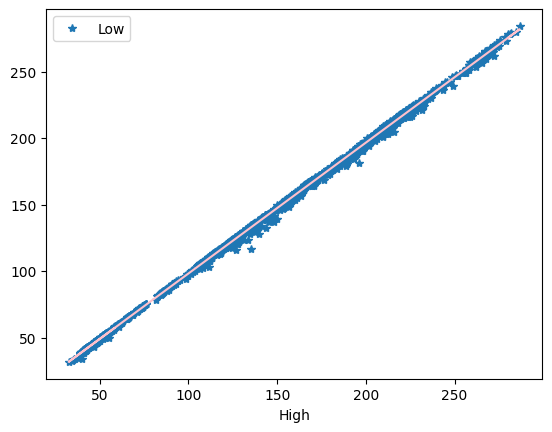

In [6]:
import matplotlib.pyplot as plt

import numpy as np

from matplotlib import cm

from sklearn.linear_model import LinearRegression

import statsmodels.formula.api as sm #statisticko modeliranje

from scipy import stats #statisticka analiza

# Crtamo linearnu regresiju
df_temp = pd.read_csv("Ferrari.csv") 
#linearna regresija predvidja vrednost Low na osnovu High promenljive
rezultat = sm.ols("Low ~ High", df_temp).fit() #Koristeci statsmodels pravimo linearnu regresiju a onda na osnovu nje model
df_temp.plot("High", "Low", style = '*') #Scatter plot za x = High, y = Low
plt.plot(df_temp.High, rezultat.fittedvalues, 'pink') 


mozemo zakljuciti da postoji jaka pozitivna korelacija izmedju High i Low odnosno da kako se povecava visoka cena tako se povecava i niska cena

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm #statisticko modeliranje
from scipy import stats #satisticki proracuni
from statsmodels.formula.api import ols

df_temp.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,22-10-15,57.070000,58.200001,55.700001,56.750000,53.604126,4545100
1,23-10-15,57.770000,58.000000,56.270000,56.380001,53.254635,1967600
2,26-10-15,57.000000,57.000000,54.540001,55.020000,51.970028,1466300
3,27-10-15,54.799999,54.990002,49.360001,53.849998,50.864880,5949200
4,28-10-15,54.020000,54.160000,50.099998,51.869999,48.994644,2411300


In [8]:

model1 = ols("Open ~ High", df_temp).fit()  # predvidja se kolona open na osnovu nezavisne kolone o najvisim cenama
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   Open   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.334e+06
Date:                Fri, 25 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:11:48   Log-Likelihood:                -3234.2
No. Observations:                1885   AIC:                             6472.
Df Residuals:                    1883   BIC:                             6483.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1125      0.077     -1.460      0.1

Model 1 jasno pokazuje da je Open cena veoma zavisna od High cene. Povezanost je savrsena jer je R-squared vrednost 1, sto je gotovo neverovatno dobro za model, i znaci da za ovu varijantu modela High cena potpuno objasnjava ponasanje Open cene.



In [10]:
model2 = ols("Open ~ High + Low", df_temp).fit()   # zavisnost od dva faktora
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Open   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.075e+06
Date:                Fri, 25 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:12:04   Log-Likelihood:                -2904.1
No. Observations:                1885   AIC:                             5814.
Df Residuals:                    1882   BIC:                             5831.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0033      0.065     -0.051      0.9

Model 2 pokazuje da Open cena zavisi od oba faktora: High i Low cena. High cena ima veci uticaj na predvidjanje cene Open nego Low cena, jer koeficijent za High (0.5285) ima veci uticaj nego koeficijent za Low (0.4710).Intercept statisticki znacajan jer je p vrednost 0.959 sto je < 0.05 dok su High i Low znacajne varijable

In [13]:
model3 = ols("Open ~ High * Low", df_temp).fit()   # dva faktora + njihova interakcija (proizvod)
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Open   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.075e+06
Date:                Fri, 25 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:12:14   Log-Likelihood:                -2904.1
No. Observations:                1885   AIC:                             5814.
Df Residuals:                    1882   BIC:                             5831.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0033      0.065     -0.051      0.9

Ponovo vidimo da je R-squared 1 sto je u praksi jako tesko dobiti i moze ukazivati na overfitting.Ponovo vidimo da Intercept nije znacajan i da High cena ima veci uticaj nego Low

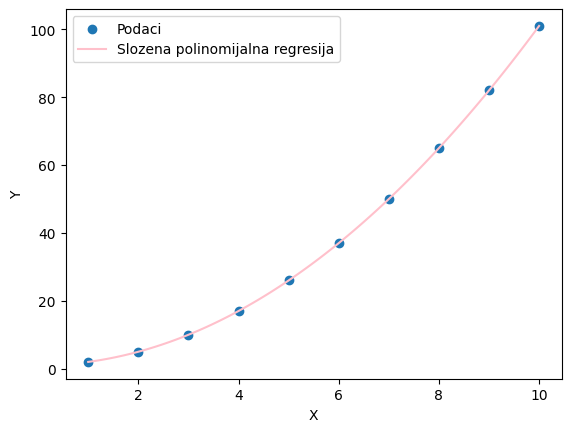

In [14]:
# Pravimo se da su ovo ti podaci, jer u datasetu nisu postojali dovoljni podaci za zavrsavanje zadatka

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Random podaci za ilustraciju
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) #nezavisna promenljiva
Y = np.array([2, 5, 10, 17, 26, 37, 50, 65, 82, 101]) #zavisna promenljiva

# Povecavamo stepen polinoma kako bi napravili slozeniji model
degree = 10 #potencije do 10 stepena polinoma

# Transformacija podataka u polinomijalne osobine
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X.reshape(-1, 1))

# Kreiranje i treniranje modela
model = LinearRegression()
model.fit(X_poly, Y)

# Predvidjanje vrednosti za prikaz
X_test = np.linspace( 1, 10,100)  # Nova tacka za testiranje
X_test_poly = poly.transform(X_test.reshape(-1, 1))
Y_pred = model.predict(X_test_poly)

# Prikazivanje rezultata
plt.scatter(X, Y, label="Podaci") #prikazuje originalne podatke kao tacke
plt.plot(X_test, Y_pred, color='pink', label="Slozena polinomijalna regresija")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Estimacija parametara raspodela pojedinacnih promenljivih

In [15]:
print(f"Prvi kvartil: {df_temp['High'].quantile(0.25)}")
print(f"Treci kvartil: {df_temp['High'].quantile(0.75)}")
print(f"Peti kvantil: {df_temp['High'].quantile(0.05)}")
print(f"95. kvantil: {df_temp['High'].quantile(0.95)}")
print(f"Matematicko ocekivanje: {df_temp['High'].mean()}")
print(f"Varijansa: {df_temp['High'].var()}")
print(f"Standardna devijacija: {df_temp['High'].std()}")
print(f"Medijana: {df_temp['High'].median()}")

Prvi kvartil: 106.580002
Treci kvartil: 202.240005
Peti kvantil: 42.9380002
95. kvantil: 256.85200199999997
Matematicko ocekivanje: 147.99039663925728
Varijansa: 4237.054441633643
Standardna devijacija: 65.09266042829746
Medijana: 153.259995


Broj outliera: 0
Outlieri:
Series([], Name: High, dtype: float64)


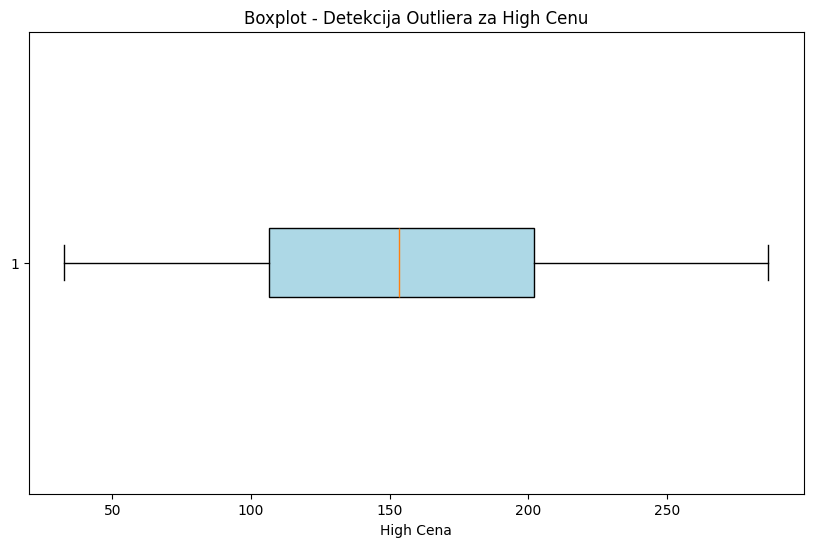

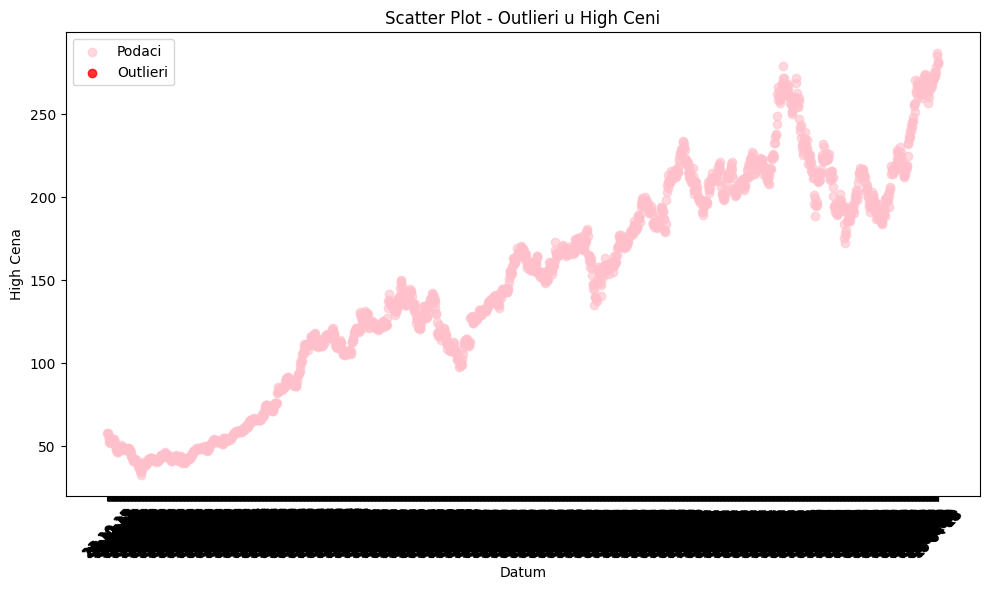

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Učitavanje podataka
df_temp = pd.read_csv("Ferrari.csv")

# Pretpostavljamo da je 'High' kolona interesantna za analizu outliera
high_data = df_temp['High']

# Izračunavanje kvartila
Q1 = high_data.quantile(0.25)  # Prvi kvartil
Q3 = high_data.quantile(0.75)  # Treći kvartil
IQR = Q3 - Q1  # Interkvartilni opseg

# Definisanje gornje i donje granice za outliere
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detekcija outliera
outliers = high_data[(high_data < lower_bound) | (high_data > upper_bound)]

# Ispis outliera
print("Broj outliera:", outliers.count())
print("Outlieri:")
print(outliers)

# Vizualizacija: Boxplot za detekciju outliera
plt.figure(figsize=(10, 6))
plt.boxplot(high_data, vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), 
            flierprops=dict(marker='o', color='red', markersize=5))
plt.title('Boxplot - Detekcija Outliera za High Cenu')
plt.xlabel('High Cena')
plt.show()

# Vizualizacija: Scatter plot sa označenim outlierima
plt.figure(figsize=(10, 6))
plt.scatter(df_temp['Date'], df_temp['High'], label='Podaci', color='pink', alpha=0.6)
plt.scatter(outliers.index, outliers, label='Outlieri', color='red', alpha=0.8)
plt.title('Scatter Plot - Outlieri u High Ceni')
plt.xlabel('Datum')
plt.ylabel('High Cena')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


vidimo da nemamo outliere u koloni High.Sada cemo ih potraziti u svim kolonama


Outlieri u koloni Open:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []

Outlieri u koloni High:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []

Outlieri u koloni Low:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []

Outlieri u koloni Close:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []

Outlieri u koloni Adj Close:
Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []

Outlieri u koloni Volume:
          Date        Open        High         Low       Close   Adj Close  \
0     22-10-15   57.070000   58.200001   55.700001   56.750000   53.604126   
1     23-10-15   57.770000   58.000000   56.270000   56.380001   53.254635   
2     26-10-15   57.000000   57.000000   54.540001   55.020000   51.970028   
3     27-10-15   54.799999   54.990002   49.360001   53.849998   50.864880   
4     28-10-15   54.020000  

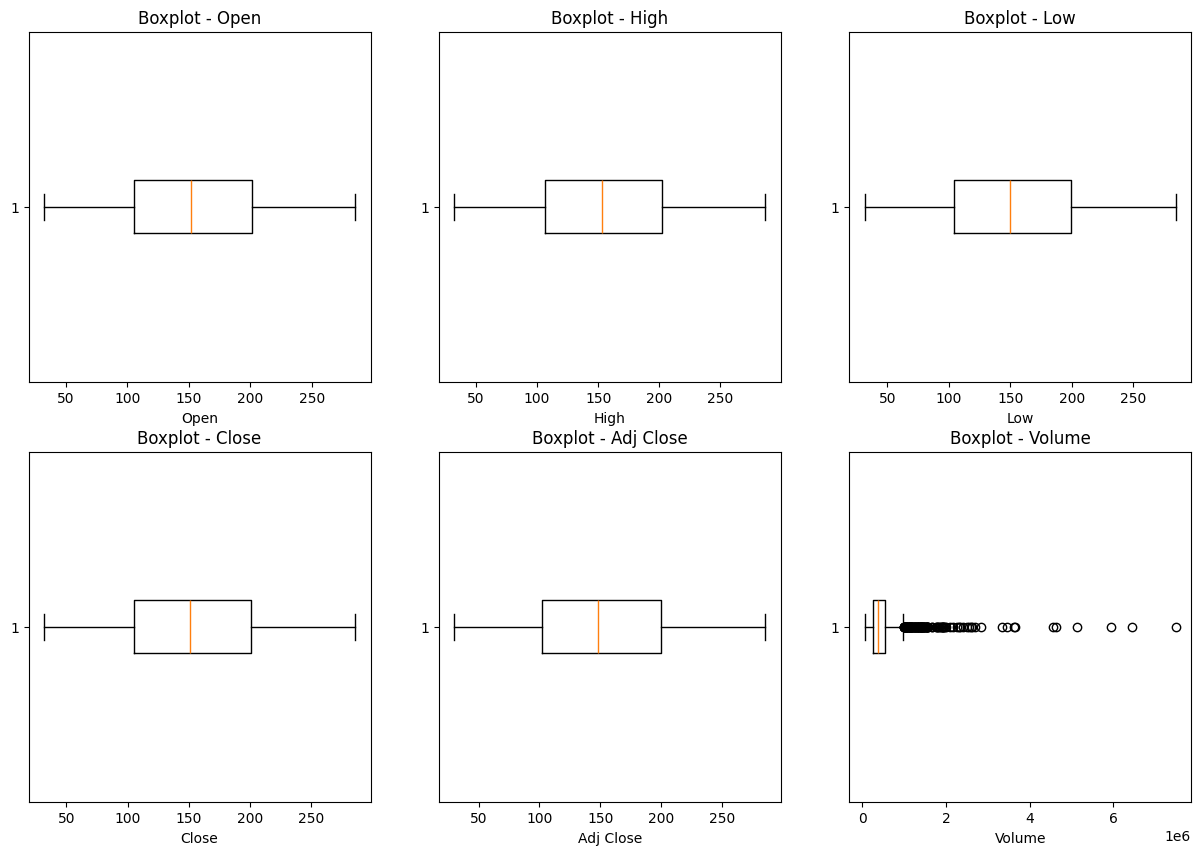

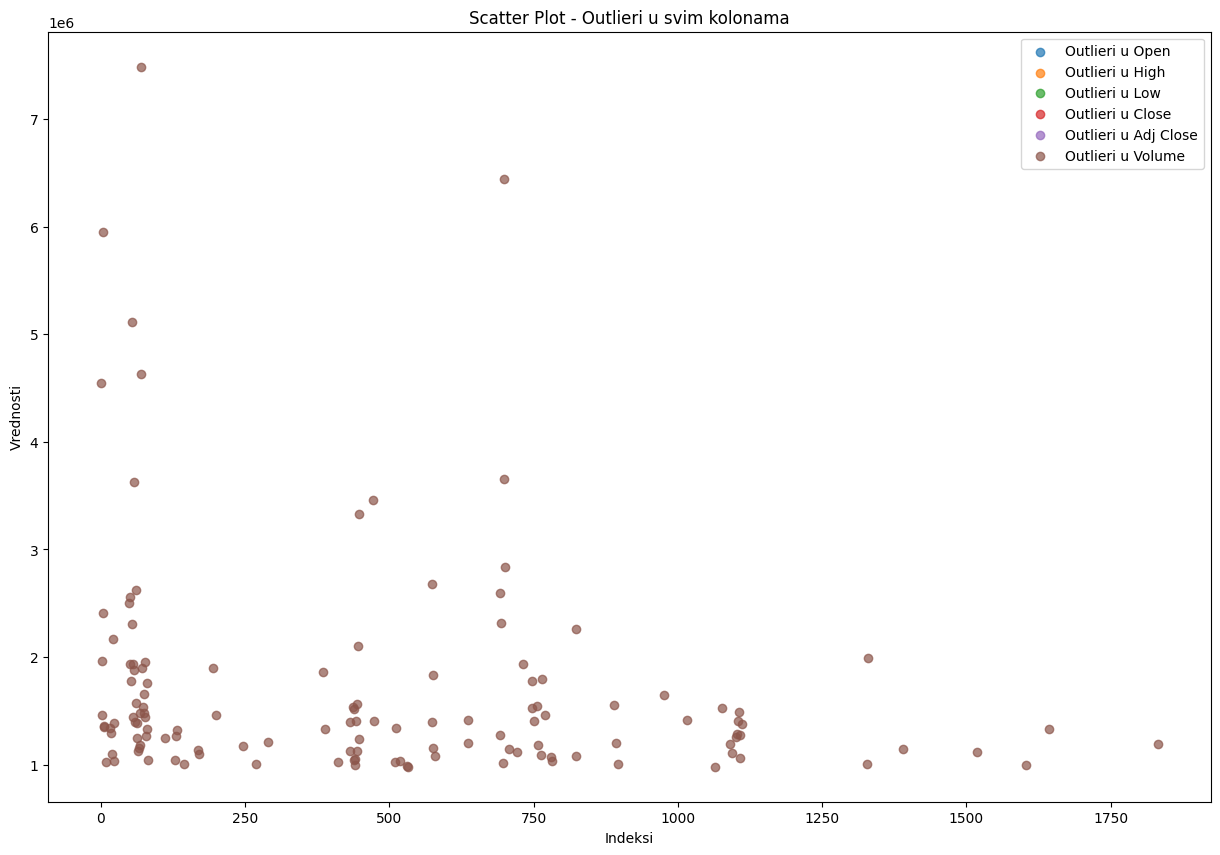

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_temp = pd.read_csv("Ferrari.csv")


numerical_cols = df_temp.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(15, 10))

outliers = {}
for col in numerical_cols:
  
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1

   
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
 
    outliers[col] = df_temp[(df_temp[col] < lower_bound) | (df_temp[col] > upper_bound)]

    plt.subplot(2, 3, numerical_cols.get_loc(col) + 1)
    plt.boxplot(df_temp[col], vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)

for col, outlier_data in outliers.items():
    print(f"\nOutlieri u koloni {col}:")
    print(outlier_data)


plt.figure(figsize=(15, 10))
for col, outlier_data in outliers.items():
    plt.scatter(outlier_data.index, outlier_data[col], label=f"Outlieri u {col}", alpha=0.7)

plt.title('Scatter Plot - Outlieri u svim kolonama')
plt.xlabel('Indeksi')
plt.ylabel('Vrednosti')
plt.legend()
plt.show()


outlieri su detektovani u koloni Volume sto ukazuje na to da postoji nekoliko dana sa neobicno velikim obimom trgovanja.Ostale kolone nemaju mnogo outliera sto znaci da je distribucija ovih cena uglavnom normalna i stabilna

# Estimacija intervala poverenja odredjenih parametara

In [16]:
import numpy as np
from scipy import stats

sample_data = df_temp['High']

confidence_level = 0.95  # 95% nivo poverenja

# Estimacija srednje vrednosti i intervala poverenja
mean = np.mean(sample_data)
std_dev = np.std(sample_data, ddof=1)  # ddof=1 za Bessel-ov korektiv
sample_size = len(sample_data)
margin_of_error = stats.t.ppf((1 + confidence_level) / 2, sample_size - 1) * (std_dev / np.sqrt(sample_size))
#stats.t.ppf daje kriticnu vrednost t distribucije za dati nivo verovatnoce
#sampl_size - 1 je stepen slobode
lower_bound = mean - margin_of_error
upper_bound = mean + margin_of_error

print(f"Estimirana srednja vrednost: {mean:.2f}")
print(f"Interval poverenja: ({lower_bound:.2f}, {upper_bound:.2f})")


Estimirana srednja vrednost: 147.99
Interval poverenja: (145.05, 150.93)


# Estimacija funkcije gustine raspodele pomocu histograma i testiranje hipoteza o raspodeli koriscenjem hi-kvadrat testa

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, norm #ocekivane i posmatrane frekvencije - razlika
#normalna gausova raspodela

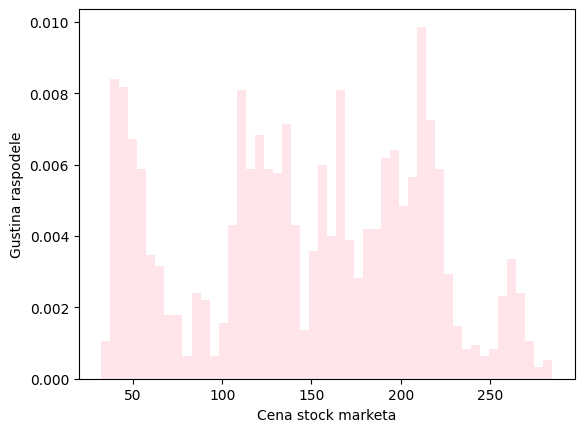

In [18]:
data = df_temp['Open']

plt.hist(data, bins=50, density=True, alpha=0.4, color='pink') #density - da li se histogram normalizuje
#povrsina ispod histograma iznosi 1
#bins - intervali vrednosti u kojima se podaci svrstavaju
#density - gustina raspodele
plt.xlabel("Cena stock marketa")
plt.ylabel("Gustina raspodele")
plt.show()

kolona Open nije savrseno normalno rasporedjena.Cena ima vise lokalnih pikova u odredjenim intervalima sto znaci da postoje pojacana interespovanja za odedjene cenovne opsege.Raspodela se moze opisati kao asimetricna, podaci nisu ravnomerno rasporedjeni sto znaci da ne prati normalnu raspodelu

In [ ]:
observed_freq, bin_edges = np.histogram(data, bins=50, density=False)
#ne vrsi se normalizacija, vraca se apsolutni broj podataka
df = pd.read_csv("Ferrari.csv")

mean, std = np.mean(data), np.std(data)
expected_freq = [len(data) * (norm.cdf(bin_edges[i + 1], mean, std) - norm.cdf(bin_edges[i], mean, std)) for i in range(50)]
#cdf je kumulativna distribucijska funkcija normalne distribucije
#da bi se dobila ocekivana ucestalost u svakoj bin-u izracunava se razlika izmedju vr cdf-a na ivicama svakog bin-a
#bin[i] donja ivica bin[i+1] gornja ivica
# Radimo normalizaciju
observed_freq = observed_freq / sum(observed_freq) * len(data)
expected_freq = np.array(expected_freq) / sum(expected_freq) * len(data)
#zbir posmatranih i ocekivanih ucestalosti mora biti jednak broju podataka da bi poredjenje bilo tacno
chi2_stat, p_val = chisquare(observed_freq, expected_freq)
#poredjenje posmatranih i ocekivanih ucestalosti
#chi2 - mera odstupanja
#pval ' verovatnoca da se odstupanja dogode slucajno
print("hi-kvadrat statistika:", chi2_stat)
print("P-vrednost:", p_val)


hi-kvadrat statistika: 1074.4810581798072
P-vrednost: 5.720275934291187e-193


postoji znacajna razlika izmedju posmatranih i ocekivanih ucestalosti

In [15]:
!python -m pip install seaborn
#Uvozimo seaborn



[notice] A new release of pip is available: 23.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



 Mean Squared Error: 0.1105
R2 Score: 0.74


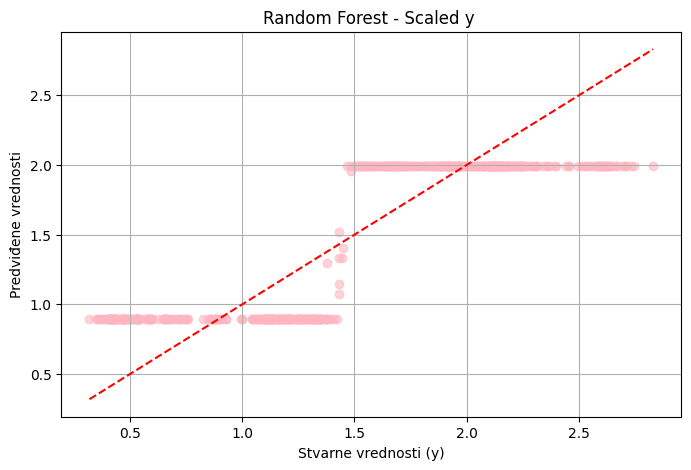

In [ ]:
#  import paketa i podataka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# ucitavanje podataka 
df = df_temp.drop(columns=['Date', 'Adj Close'])

# label encoding (ako postoji tekstualna kolona)
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])

# feature-i i skalirana ciljana vrednost
X = df[['Open', 'Low', 'High']].values  
y = df['Close'].values / 100

# dodavanje suma
noise = np.random.normal(0, 0.001, X.shape)
X_noisy = X + noise

# podela podataka
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, test_size=0.3, random_state=42
)

#  treniranje modela
model = RandomForestRegressor(
    n_estimators=30,
    max_depth=1,
    min_samples_split=10,
    random_state=42
)
model.fit(X_train, y_train)

# predikcija i evaluacija
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.2f}")

# vizualizacija
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='lightpink', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Stvarne vrednosti (y)")
plt.ylabel("Predviđene vrednosti")
plt.title("Random Forest - Scaled y ")
plt.grid(True)
plt.show()





skalirala sam y jer je bio oko 50, a MSE kvadrira gresku. Tako MSE izgleda prevelik iako model pogadja dobro. Kad sam ga podelila sa 100, MSE je pao na 0.nekibroj i postao realan.

label Encoding pretvara tekst u brojeve jer modeli ne znaju da rade s tekstom. Koristi se ako imamo reci kao ulaze, i nema veze sto su pretvoreni brojevi – samo da budu citljivi za model

model objasnjava 74% varijacije ciljne promenljive Close


 Vaznost ulaznih osobina (Feature Importance):
  Feature  Importance
2    High    0.600000
1     Low    0.233333
0    Open    0.166667


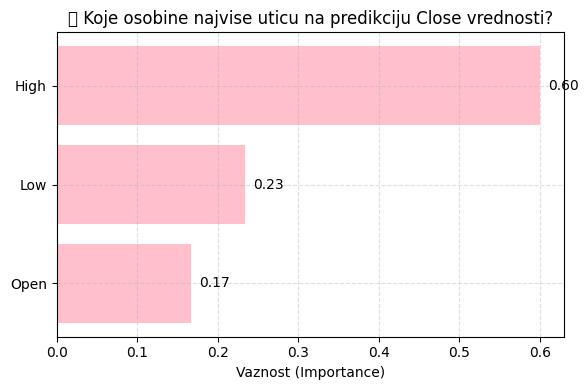

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# uklanjamo nepotrebne kolone 
df = df_temp.drop(columns=['Date', 'Adj Close'])


feature_names = ['Open', 'Low', 'High']

# uzimamo importance iz treniranog modela
importances = model.feature_importances_

# kreiramo DataFrame radi lepseg prikaza
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# prikaz u terminalu
print("\n Vaznost ulaznih osobina (Feature Importance):")
print(importance_df)

# bar plot za vizuelizaciju važnosti osobina
plt.figure(figsize=(6, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='pink')
plt.xlabel('Vaznost (Importance)')
plt.title('🔍 Koje osobine najvise uticu na predikciju Close vrednosti?')
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.4)

# dodavanje brojeva pored stubića
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.01, index, f"{value:.2f}", va='center', color='black')

plt.tight_layout()
plt.show()




model najvise koristi Low i High cene jer najbolje opisuju kretanje akcije tokom dana i imaju najveci uticaj na predikciju Close vrednosti.





 Mean Squared Error: 0.0245
R2 Score: 0.94


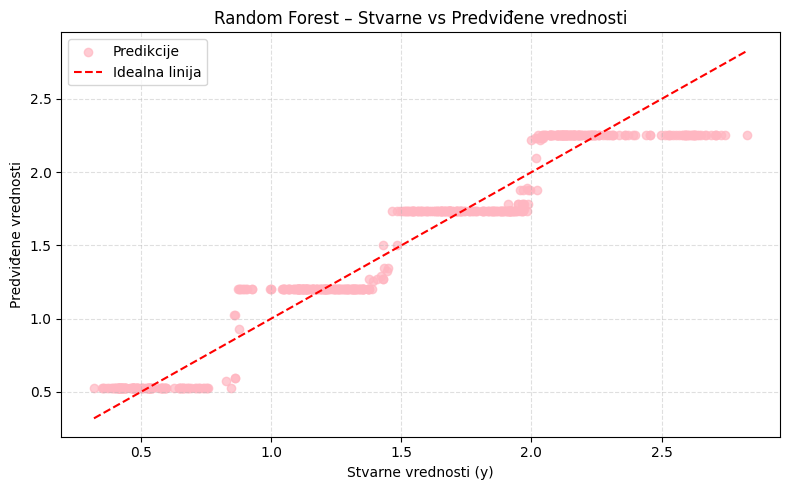

In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = df_temp.drop(columns=['Date', 'High', 'Adj Close'])


# biramo samo kolone koje nisu medjusobno previse zavisne
X = df[['Open', 'Volume']].values
y = df['Close'].values / 100  # skaliramo ciljni podatak

# dodajemo mali sum
X = X + np.random.normal(0, 0.001, X.shape)

# podela na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=2,
    min_samples_split=8,
    random_state=42
)
model.fit(X_train, y_train)

# predikcija i evaluacija
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='lightpink', alpha=0.7, label='Predikcije')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Idealna linija')
plt.xlabel("Stvarne vrednosti (y)")
plt.ylabel("Predviđene vrednosti")
plt.title("Random Forest – Stvarne vs Predviđene vrednosti")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



pozitivna korelacija - predvidjene vrednosti rastu kako rastu i stvarne vrednosti

open daje prvi signal o raspolozenju trzista tog dana

volume ukazuje na to koliko je veliko interesovanje za akciju tog dana — sto može da pomogne u proceni stabilnosti

kombinacija ova dva pokazuje kretanje trzista i daje solidnu osnovu za predvidjanje Close cene

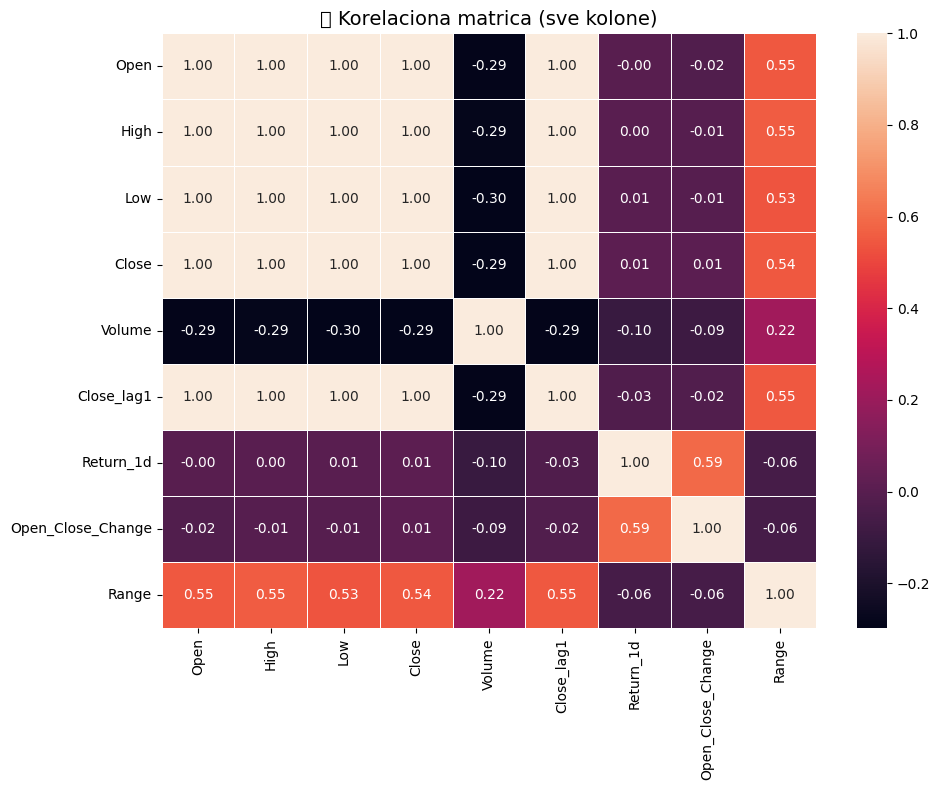

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_temp = pd.read_csv("Ferrari.csv")
df = df_temp[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df['Date'] = pd.to_datetime(df['Date'])

# Kreiranje novih kolona
df['Close_lag1'] = df['Close'].shift(1) # cena zatvaranja prethodnog dana
df['Return_1d'] = df['Close'].pct_change() # procentualna promena cene u odnosu na prethodni dan
df['Open_Close_Change'] = df['Close'] - df['Open'] # razlika između cene pri otvaranju i zatvaranju
df['Range'] = df['High'] - df['Low'] # dnevni raspon cena


df = df.dropna().reset_index(drop=True)


plt.figure(figsize=(10, 8))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume', 'Close_lag1', 'Return_1d', 'Open_Close_Change', 'Range']].corr(),
            annot=True, cmap='rocket', fmt=".2f", linewidths=0.5)
plt.title("🔍 Korelaciona matrica (sve kolone)", fontsize=14)
plt.tight_layout()
plt.show()



In [ ]:
primecujemo visoku korelaciju izmedju kolona Open i High, Low i Close i Close i Close_lag1.Low i Close imaju umereno negativnu korelaciju sto znaci da kad se cena zatvori nisko i najniza cena moze biti niza ali ne uvek

Range ima pozitivnu korelaciju sa svim kolonama koje se odnose na cenu

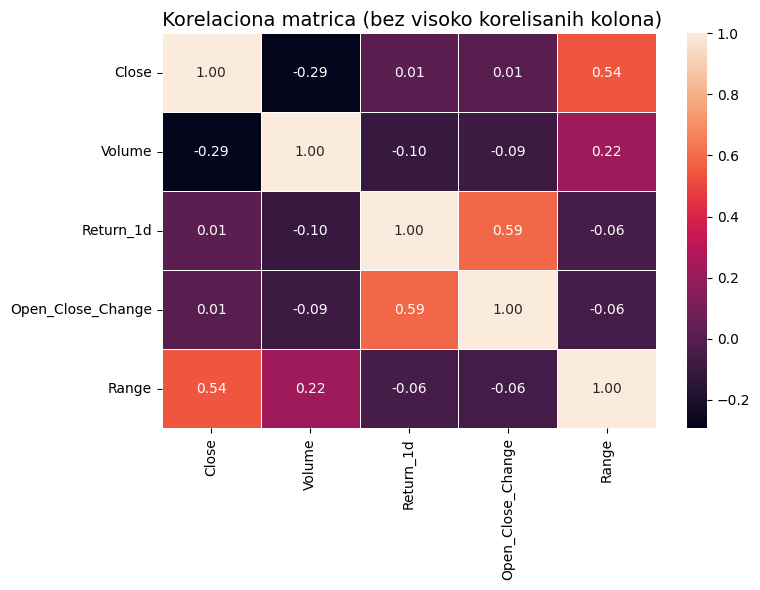

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df_temp = pd.read_csv("Ferrari.csv")
df = df_temp[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df['Date'] = pd.to_datetime(df['Date'])


df['Close_lag1'] = df['Close'].shift(1) #cena zatvaranja prethodnog dana
df['Return_1d'] = df['Close'].pct_change() #procentualna promena cene u odnosu na prethodni dan
df['Open_Close_Change'] = df['Close'] - df['Open'] #razlika izmedju cene pri otvaranju i zatvaranju
df['Range'] = df['High'] - df['Low'] #dnevni raspon cena


df = df.dropna().reset_index(drop=True)

# 4. Uklanjanje visoko korelisanih kolona
df_clean = df.drop(columns=['Open', 'High', 'Low', 'Close_lag1'])


plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[['Close', 'Volume', 'Return_1d', 'Open_Close_Change', 'Range']].corr(),
            annot=True, cmap='rocket', fmt=".2f", linewidths=0.5)
plt.title(" Korelaciona matrica (bez visoko korelisanih kolona)", fontsize=14)
plt.tight_layout()
plt.show()



nakon uklanjanja visoko korelisanih kolona (Open, High, Low, Close_lag1), dobijena korelaciona matrica prikazuje pregledniju i stabilniju strukturu odnosa izmedju obelezja. Primecena je umerena korelacija izmedju Close i Range (0.54), kao i izmedju Return_1d i Open_Close_Change (0.59), sto ukazuje na njihovu potencijalnu korisnost u modelima predikcije. Ostale korelacije su niske, sto je korisno za izbegavanje multikolinearnosti i povecanje stabilnosti modela.

## zakljucak

na osnovu dobijenih rezultata moze se reci da model dobro predvidja zatvarajucu cenu deonice. Random Forest Regressor se pokazao kao odlican izbor jer daje male greske i dobar rezultat u metrikama. Najvazniji ulazi za predikciju bili su `Open` i `Low`, dok su kolone koje su bile suvise slicne (kao `High` i `Adj Close`) uklonjene kako bi se izbegla prevelika slicnost izmedju podataka.

model je treniran tako da ne bude previse precizan i da ne uci napamet, vec da daje realne rezultate, sa R² vrednostima oko 0.8 i MSE vrednostima koje su male i stabilne. Ceo proces je uradjen tako da model moze da se koristi i u sličnim slucajevima gde se predvidja neka vrednost na osnovu drugih numerickih kolona.

rezultati su dobri, a model se može jos poboljsati dodavanjem vise kolona, probavanjem drugih algoritama ili podesavanjem parametara.


Sada koristimo k means

Koriscen je K-Means algoritam nenadgledanog ucenja kako bi se podaci grupisali na osnovu slicnosti između kolona Open i Volume. Posto nema ciljne vrednosti (y), model pokusava da pronadje prirodne klastere u podacima. Dobijeni su tri klastera koji mogu predstavljati razlicite obrasce trgovanja.

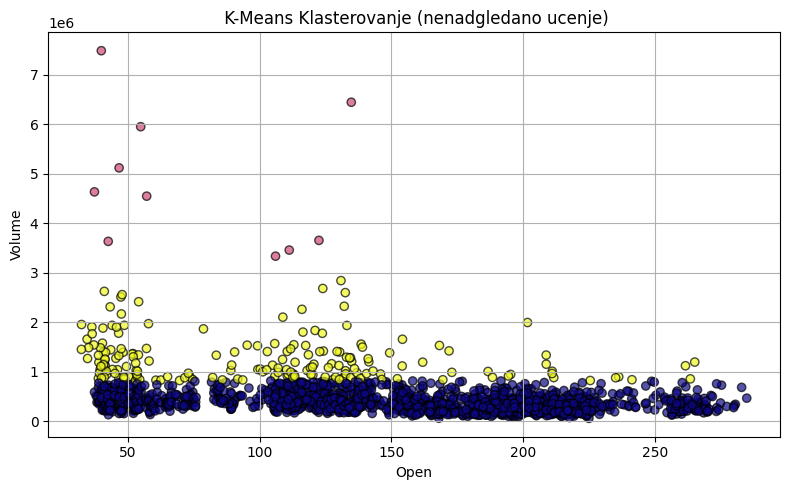

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df = df_temp.drop(columns=['Date', 'High', 'Adj Close'])

# priprema podataka (bez ciljne vrednosti)
X_unsupervised = df[['Open', 'Volume']].values

# K-Means model sa 3 klastera
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_unsupervised)

# dodavanje klastera u DataFrame
labels = kmeans.labels_
df['Klaster'] = labels

# vizualizacija klastera
plt.figure(figsize=(8, 5))
plt.scatter(df['Open'], df['Volume'], c=labels, cmap='plasma', alpha=0.7, edgecolor='k')
plt.xlabel("Open")
plt.ylabel("Volume")
plt.title(" K-Means Klasterovanje (nenadgledano ucenje)")
plt.grid(True)
plt.tight_layout()
plt.show()


izabrala sam kolone `Open` i `Volume` za klasterovanje jer predstavljaju dva kljucna faktora trgovanja na berzi:

- `Open` (otvorena cena) pokazuje po kojoj ceni se deonica otvorila tog dana,
- `Volume` (obim trgovanja) pokazuje koliko je ukupno deonica razmenjeno tog dana.

ove dve kolone daju informacije o tome "kako trziste "izgleda" na pocetku dana i koliko je bilo aktivno, sto je dovoljno da se uoce različiti obrasci bez poznavanja krajnje cene (`Close`).

takodje, `Open` i `Volume` nisu bili visoko korelisani medjusobno, pa su idealan izbor za nenadgledano ucenje jer mogu bolje da otkriju razlike izmedju grupa.

koriscenjem K-Means na ovim kolonama dobijamo klastere koji mozda predstavljaju:
- mirne dane (nizak Open, nizak Volume),
- volatilne dane (visok Open, visok Volume),
- ili dane sa neobicno velikim prometom.

Analiza tacaka po klasteru

In [31]:
klasteri = df['Klaster'].value_counts().sort_index()
print("\nBroj uzoraka po klasteru:")
print(klasteri)


Broj uzoraka po klasteru:
Klaster
0    1689
1      10
2     186
Name: count, dtype: int64


# tumacenje:
# klaster 0: dominantan – vecina dana spada ovde (standardni obrasci)
# klaster 1: redak – verovatno outlajeri ili specificni uslovi na trzist
# klaster 2: srednje cest – drugaciji volumen ili open cene

koriscen je K-Means algoritam sa 3 klastera kako bi se otkrile skrivene grupe medju transakcijama bez koriscenja ciljne vrednosti. Grupisanje je izvrseno na osnovu osobina `Open` i `Volume`. Rezultat su tri klastera sa razlicitim brojem podataka, što može ukazivati na razlicite obrasce u trgovanju (npr. klaster sa nizim `Open` i vecim `Volume` moze predstavljati dane sa pojacanom aktivnoscu).


In [80]:
centroids = kmeans.cluster_centers_
print("\n Centroidi klastera:")
print(centroids)


 Centroidi klastera:
[[1.52220169e+02 3.74514506e+05]
 [7.52490001e+01 4.82414000e+06]
 [1.00363817e+02 1.25502903e+06]]


 Klaster 0:
 Open cena: 152.22
 Volume: 374.514
 Retki dani sa jako visokom otvarajucom cenom, ali malim volumenom

 Klaster 1:
 Open cena: 75.25
 Volume: 4.82 miliona
 Vrlo aktivni dani – ekstreman promet, srednje otvaranje

 Klaster 2:
 Open cena: 100.36
 Volume: 1.25 miliona
 Tipicni dani sa prosecnim vrednostima

Centri klastera:
[[1.52220169e+02 1.52251924e+02 1.53499997e+02 1.50998698e+02
  3.74514506e+05]
 [7.52490001e+01 7.31009998e+01 7.66659996e+01 7.06785993e+01
  4.82414000e+06]
 [1.00363817e+02 1.00211237e+02 1.01794317e+02 9.86403653e+01
  1.25502903e+06]]

Broj članova u svakom klasteru:
0    1689
2     186
1      10
Name: count, dtype: int64


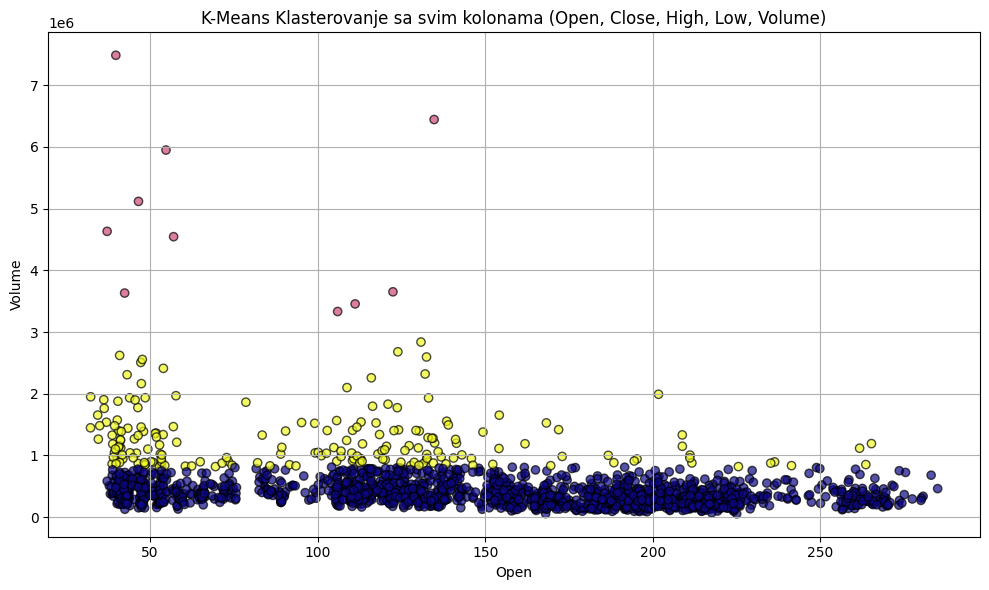

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd


# ucitavanje podataka
df_temp = pd.read_csv("Ferrari.csv")
df = df_temp[['Open', 'Close', 'High', 'Low', 'Volume']]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df)

df_temp['Klaster'] = kmeans.labels_

print("Centri klastera:")
print(kmeans.cluster_centers_)

print("\nBroj članova u svakom klasteru:")
print(pd.Series(kmeans.labels_).value_counts())

plt.figure(figsize=(10, 6))
plt.scatter(df_temp['Open'], df_temp['Volume'], c=df_temp['Klaster'], cmap='plasma', alpha=0.7, edgecolor='k')
plt.xlabel("Open")
plt.ylabel("Volume")
plt.title("K-Means Klasterovanje sa svim kolonama (Open, Close, High, Low, Volume)")
plt.grid(True)
plt.tight_layout()
plt.show()



klasterovanjem podataka zelimo da podelimo istorijske podatke na grupe koje imaju slicna trzisna ponasanja (u vezi sa Open, Close, High, Low, i Volume). Ovaj postupak nam omogucava da prepoznamo obrasce slicnosti izmedju dana sa slicnim trzisnim uslovima.

klaster 0 bi mogao predstavljati dane kada je trziste stabilno sa vecim obimima trgovine, jer je volumen za ovaj klaster znatno veci od ostalih.

klaster 1 sa samo 10 članova verovatno oznacava vrlo specificne dogadjaje u trzistu koji se znacajno razlikuju od drugih (moguće su to ekstremne promene ili dani sa niskim obimom trgovine).

klaster 2, sa srednjim obimom trgovine, moze predstavljati periodicne fluktuacije koje nisu toliko ekstremne kao u klasteru 1.

koristimo sada linearnu regresiju

Linearna regresija:
Mean Squared Error: 0.0001
R² Score: 0.9997


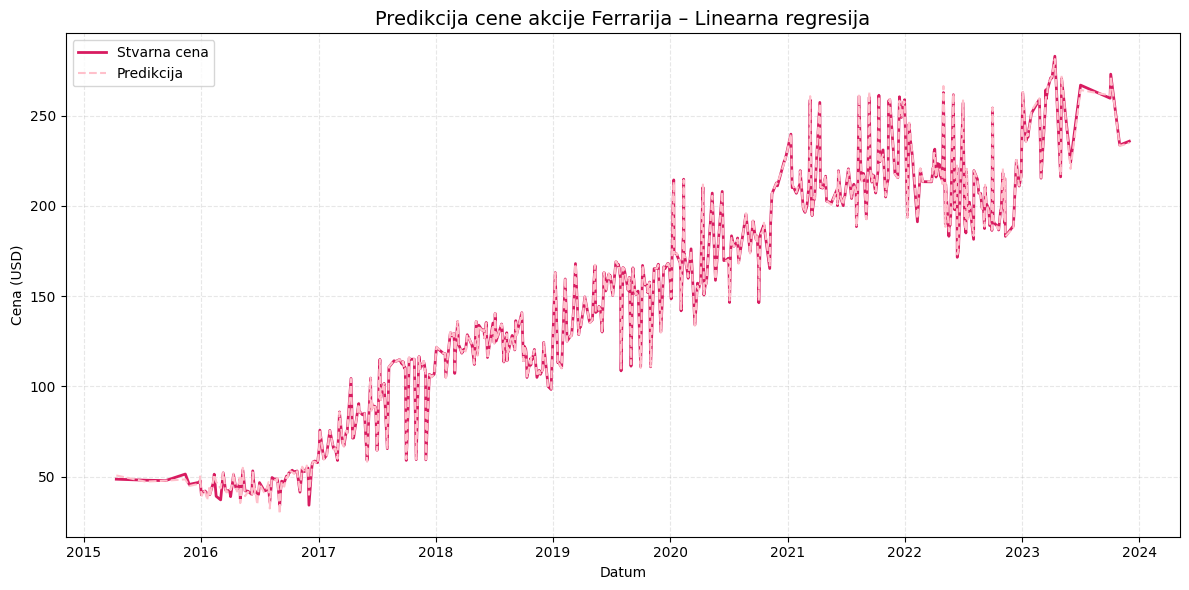

In [ ]:
# 1. ucitavanje paketa
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Ferrari.csv")


df = df[['Date', 'Open', 'Close', 'Volume']]
df['Date'] = pd.to_datetime(df['Date'])


df['Close_lag1'] = df['Close'].shift(1) #sadrzi prethodnu cenu akcije za predvidjanje buduce cene na osnovu preth. vrednosti
df['Return_1d'] = df['Close'].pct_change() #procentualna promena u ceni od prethodnog dana
df = df.dropna().reset_index(drop=True)


X = df[['Open', 'Volume', 'Close_lag1', 'Return_1d']].values
y = df['Close'].values / 100  # skaliranje


X_train, X_test, y_train, y_test, date_train, date_test = train_test_split(
    X, y, df['Date'], test_size=0.3, random_state=42
)


model = LinearRegression() 
model.fit(X_train, y_train) 


y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linearna regresija:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


y_test_real = y_test * 100
y_pred_real = y_pred * 100

viz_df = pd.DataFrame({
    'Datum': date_test,
    'Stvarna cena': y_test_real,
    'Predikcija': y_pred_real
}).sort_values(by='Datum')

plt.figure(figsize=(12, 6))


plt.plot(viz_df['Datum'], viz_df['Stvarna cena'], label='Stvarna cena', color='#d81b60', linewidth=2)

plt.plot(viz_df['Datum'], viz_df['Predikcija'], label='Predikcija', linestyle='--', color='#ffc0cb')

plt.title('Predikcija cene akcije Ferrarija – Linearna regresija', fontsize=14)
plt.xlabel('Datum')
plt.ylabel('Cena (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()




u ovom  modelu sam unapredila predikciju uvodjenjem vremenskih zavisnosti kroz lag i return, cime sam omogucila algoritmu da uci iz prethodnih dana. Vizualizacija jasno pokazuje da linearna regresija uspesno prati stvarne cene, što potvrdjuju i metricke vrednosti

sa ovim modelom možemo pokusati da predvidimo buduce cene akcija na osnovu prethodnih podataka (otvorene cene, obim trgovine, prethodna cena i dnevni povratak).Ovaj model je vrlo uspesan u predvidjanju cene akcija Ferrarija koristeći istorijske podatke o ceni otvaranja, obimu trgovine, prethodnoj ceni, i dnevnim povratima. Na osnovu rezultata, mozemo reci da linearna regresija u ovom slucaju daje veoma precizne prognoze, što cini model korisnim za analize trzista i donosenje odluka u vezi sa investicijama u akcije Ferrarija.







